In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

---

### 1. Redes multicapa con nn.Module

In [15]:
# Datos de XOR
X = torch.tensor([[0., 0.],
                  [0., 1.],
                  [1., 0.],
                  [1., 1.]])

y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]])


class MLP(nn.Module):
    def __init__(self, use_activation=True):
        super(MLP, self).__init__()
        self.hidden = nn.Linear(2, 8)
        self.output = nn.Linear(8, 1)
        self.activation = nn.Tanh() if use_activation else nn.Identity()

    def forward(self, x):
        return self.output(self.activation(self.hidden(x)))

def train(model, X, y, epochs=2000, lr=0.05):
    loss_fn = nn.BCEWithLogitsLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

def model_accuracy(model, X, y):
    with torch.no_grad():
        pred = (model(X) > 0).float() 
    return (pred == y).float().mean().item()

def plot(model, X, y):
    g = torch.linspace(-0.5, 1.5, 200)
    xx, yy = torch.meshgrid(g, g, indexing='xy')
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)
    with torch.no_grad():
        prob = torch.sigmoid(model(grid)).reshape(xx.shape)
    plt.contourf(xx.numpy(), yy.numpy(), prob.numpy(), levels=[0, 0.5, 1],
                 colors=['#a6cee3', '#fb9a99'], alpha=0.6)
    plt.contour(xx.numpy(), yy.numpy(), prob.numpy(), levels=[0.5], colors='k')
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze().numpy(), cmap='coolwarm',
                edgecolors='k', s=150)
    plt.show()

Pérdida final: 0.0000
Exactitud: 100%


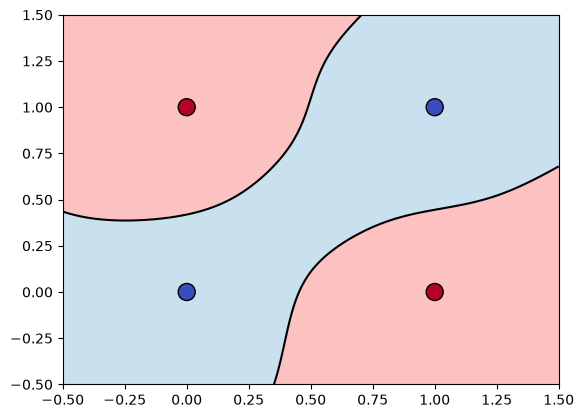

In [16]:
mlp = MLP()
loss_mlp = train(mlp, X, y)

print(f'Pérdida final: {loss_mlp[-1]:.4f}')
print(f'Exactitud: {model_accuracy(mlp, X, y) * 100:.0f}%')
plot(mlp, X, y)

In [ ]:
# Version sin función de activación entre las capas

torch.manual_seed(42)
mlp_lineal = MLP(usar_activacion=False)
perdidas_lineal = entrenar(mlp_lineal, X, y)

print(f'Pérdida final: {perdidas_lineal[-1]:.4f}')
print(f'Exactitud: {exactitud(mlp_lineal, X, y) * 100:.0f}%')
graficar_frontera(mlp_lineal, X, y, 'MLP sin activación: frontera lineal')

plt.plot(perdidas_mlp, label='Con tanh')
plt.plot(perdidas_lineal, label='Sin activación')
plt.xlabel('Época')
plt.ylabel('Pérdida (BCE)')
plt.legend()
plt.show()